<a href="https://colab.research.google.com/github/tinadams/Carisurg-Week-0/blob/main/Day3-DataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
# Environment setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


# Student Challenge

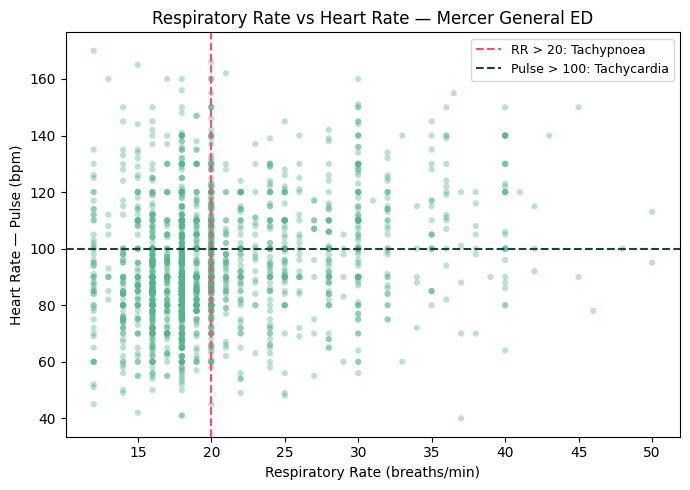

Saved: rr_vs_pulse_scatter.png


In [79]:
# Created by: Tessa Adams
# Date: May 22, 2026
#
#
# Clinical Question 1:
# Is there a relationship between respiratory rate (RR)
# and heart rate (pulse) in emergency department patients?
#
# Plot Type:
# Scatter Plot
#
# Clinical Meaning:
# - This plot is intended to explore the relationship between RR and pulse
# - Higher RR and pulse together may indicate higher stress levels or illness severity
# - These patients may need closer monitoring.
#
# The plot shows that the relationship between RR and pulse is not strong
# or consistent across all patients in the dataset.

# Create figure and axis object
fig, ax = plt.subplots(figsize=(7, 5))

# Scatter plot of respiratory rate (RR) vs pulse (heart rate)
ax.scatter(df['RR'],
           df['pulse'],
           alpha=0.4,
           s=20,
           color='#52B788',
           edgecolors='none')

# Clinical reference lines
# standard clinical vital sign thresholds
ax.axvline(x=20,
           color='#FF4D6D',
           linestyle='--',
           linewidth=1.5,
           label='RR > 20: Tachypnoea')

ax.axhline(y=100,
           color='#1B4332',
           linestyle='--',
           linewidth=1.5,
           label='Pulse > 100: Tachycardia')

# Title, label and other formatting
ax.set_title('Respiratory Rate vs Heart Rate — Mercer General ED',
             fontsize=12)

ax.set_xlabel('Respiratory Rate (breaths/min)')
ax.set_ylabel('Heart Rate — Pulse (bpm)')

ax.legend(fontsize=9)

plt.tight_layout()

# Save figure
plt.savefig('rr_vs_pulse_scatter.png',
            dpi=100,
            bbox_inches='tight')

plt.show()

print("Saved: rr_vs_pulse_scatter.png")

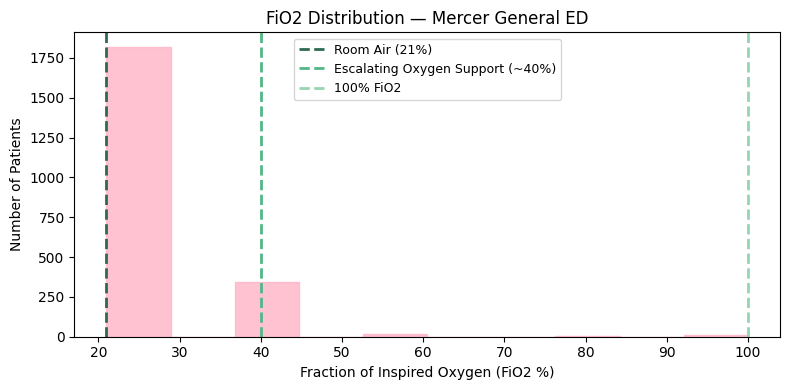

Saved: fio2_histogram.png


In [80]:
# Clinical Question 2A:
# Are most patients receiving normal oxygen levels (FiO2),
# or do we see evidence of patients requiring oxygen support?
#
# Plot Type:
# Histogram
#
# Clinical Meaning:
# - FiO2 = 21% represents room air
# - ~40% FiO2 represents a moderate-to-high oxygen support threshold.
# - 100% FiO2 may indicate critically ill ventilated patients
#
# The plot suggests most patients are clustered at lower FiO2 values,
# indicating many are likely on room air or minimal oxygen support,
# with fewer patients requiring higher levels of oxygen supplementation


# Create figure and axis object
fig, ax = plt.subplots(figsize=(8, 4))

# Plot histogram of FiO2 values in the dataset
ax.hist(df['Fio2'],
        bins=10,
        color='#FFB3C6',
        edgecolor='#FFB3C6',
        alpha=0.8)

# Clinical reference lines
# Room air baseline (21% oxygen)
# Represents patients not receiving supplemental oxygen
ax.axvline(x=21, color='#2D6A4F', linestyle='--',
           linewidth=2, label='Room Air (21%)')

# Moderate to high oxygen support threshold (~40%)
# May indicate patients requiring supplemental oxygen therapy
ax.axvline(x=40, color='#52B788', linestyle='--',
           linewidth=2, label='Escalating Oxygen Support (~40%)')

# Maximum oxygen concentration (100%)
# Often associated with ventilated or critically ill patients
ax.axvline(x=100, color='#95D5B2', linestyle='--',
           linewidth=2, label='100% FiO2')

# Title, label and other formatting
ax.set_title('FiO2 Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Fraction of Inspired Oxygen (FiO2 %)')
ax.set_ylabel('Number of Patients')

ax.legend(fontsize=9)

plt.tight_layout()

# Save figure
plt.savefig('fio2_histogram.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: fio2_histogram.png")

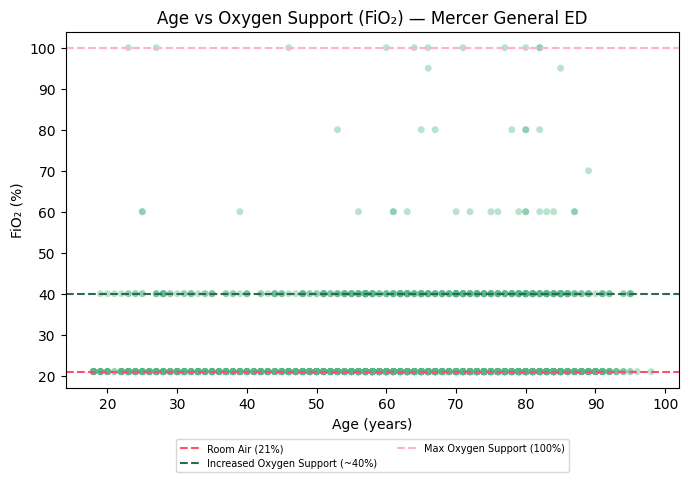

Saved: age_vs_fio2_scatter.png


In [83]:
# Clinical Question 2B:
# Is there a relationship between patient age and oxygen support (FiO2)?
#
# Plot Type:
# Scatter Plot
#
# Clinical Meaning:
# - This plot explores whether age is associated with oxygen support requirements (FiO2)
# - Higher FiO2 values suggest increased respiratory support needs
#
# The plot shows patients of varying ages appear across both low and higher FiO2 levels,
# with no obvious linear pattern between age and oxygen support

# Create figure and axis object
fig, ax = plt.subplots(figsize=(7, 5))

# Scatter plot of Age vs FiO2
# Each point represents a patient
ax.scatter(df['Age'],
           df['Fio2'],
           alpha=0.4,
           s=25,
           color='#52B788',
           edgecolors='none')

# Clinical reference line for room air (21% FiO2)
ax.axhline(y=21,
           color='#FF4D6D',
           linestyle='--',
           linewidth=1.5,
           label='Room Air (21%)')

# Clinical reference line: Increased oxygen support (~40% FiO2)
ax.axhline(y=40,
           color='#2D6A4F',
           linestyle='--',
           linewidth=1.5,
           label='Increased Oxygen Support (~40%)')

# Upper threshold: maximum oxygen support (100% FiO2)
ax.axhline(y=100,
           color='#FFB3C6',
           linestyle='--',
           linewidth=1.5,
           label='Max Oxygen Support (100%)')

# Title and label formatting
ax.set_title('Age vs Oxygen Support (FiO₂) — Mercer General ED',
             fontsize=12)

ax.set_xlabel('Age (years)')
ax.set_ylabel('FiO₂ (%)')

ax.legend(fontsize=7, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

plt.tight_layout()

# Save figure
plt.savefig('age_vs_fio2_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: age_vs_fio2_scatter.png")

In [82]:
# Always save plots before posting to Discord or GitHub
# Use dpi=100 for Discord (smaller file), dpi=150 for GitHub README

# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  age_vs_fio2_scatter.png             (47 KB)
  fio2_histogram.png                  (33 KB)
  rr_vs_pulse_scatter.png             (94 KB)
